# 🔍 Autoencoder Anomaly Detection on MNIST  
### Unsupervised Deep Learning with TensorFlow/Keras

This project builds a **convolutional autoencoder** to detect anomalies on the MNIST dataset.

We treat:
- **Digit 0 → Normal data**
- **Digits 1–9 → Anomalies**

The autoencoder is trained **only on normal samples (0)**, learning how to reconstruct them.  
When shown anomalous images, it fails to reconstruct them well → producing **high reconstruction error**, which we use to detect anomalies.

### 🧠 Why is this project valuable?
- Demonstrates **unsupervised learning**
- Shows understanding of **representation learning**
- Uses **TensorFlow/Keras**, aligned with Andrew Ng's style
- Excellent visualizations (reconstruction vs anomaly)
- Perfect for Applied Scientist interview


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models


## 📥 Loading MNIST and Preparing Normal vs Anomaly Sets

We load MNIST and keep only digit **0** as normal training data.  
Digits **1–9** will be used for anomaly testing.


In [2]:
# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize & reshape
x_train = x_train.astype("float32") / 255.
x_test  = x_test.astype("float32") / 255.

x_train = np.expand_dims(x_train, axis=-1)
x_test  = np.expand_dims(x_test, axis=-1)

# Keep only digit 0 for training
train_norm = x_train[y_train == 0]

# Create test sets
test_norm = x_test[y_test == 0]      # normal samples
test_anom = x_test[y_test != 0]      # anomalies

train_norm.shape, test_norm.shape, test_anom.shape


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 8s 1us/step


((5923, 28, 28, 1), (980, 28, 28, 1), (9020, 28, 28, 1))

## 🏗️ Building the Convolutional Autoencoder

The autoencoder has two parts:

### 🔹 Encoder  
Learns a compressed latent representation (bottleneck).  
Consists of convolution + downsampling layers.

### 🔹 Decoder  
Reconstructs the original image from the latent vector.  
Uses transposed convolutions to upsample back to 28×28.

The model learns to accurately reconstruct **normal** samples (digit 0) and fails on **anomalies**, producing a higher reconstruction error.


In [9]:
input_img = tf.keras.Input(shape=(28, 28, 1))

# Encoder
x = tf.keras.layers.Conv2D(32, (3,3), activation="relu", padding="same")(input_img)
x = tf.keras.layers.MaxPooling2D((2,2), padding="same")(x)

x = tf.keras.layers.Conv2D(64, (3,3), activation="relu", padding="same")(x)
encoded = tf.keras.layers.MaxPooling2D((2,2), padding="same")(x)
# shape = (7,7,64)

# Decoder
x = tf.keras.layers.Conv2DTranspose(64, (3,3), strides=2, activation="relu", padding="same")(encoded)
# (14,14,64)

x = tf.keras.layers.Conv2DTranspose(32, (3,3), strides=2, activation="relu", padding="same")(x)
# (28,28,32)

decoded = tf.keras.layers.Conv2D(
    1, (3,3), activation="sigmoid", padding="same"
)(x)
# (28,28,1)

autoencoder = tf.keras.Model(input_img, decoded)
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_6 (Conv2DTranspose) │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_7 (Conv2DTranspose) │ (None, 28, 28, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## 🚀 Training the Autoencoder

We train the autoencoder **only on normal images (digit 0)**.  
The objective is to minimize the **reconstruction loss (MSE)** so that the network learns how normal data looks.

Later, anomalies will produce **higher reconstruction error**, allowing us to detect them.

We train for a small number of epochs since MNIST is simple and the model converges quickly.


In [10]:
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

history = autoencoder.fit(
    train_norm,
    train_norm,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_split=0.1
)


Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.1271 - val_loss: 0.0377
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0158 - val_loss: 0.0081
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0071 - val_loss: 0.0060
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0057 - val_loss: 0.0052
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0050 - val_loss: 0.0046
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0045 - val_loss: 0.0042
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0041 - val_loss: 0.0039
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0038 - val_loss: 0.0037
Epoch 9/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0036 - val_loss: 0.0035
Epoch 10/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0034 - val_loss: 0.0034
Epoch 11/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0033 - val_loss: 0.0032
Epoch 12/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0

## 🖼️ Visualizing Reconstructions: Normal vs Anomaly

We compare how the autoencoder reconstructs:

- **Normal samples (digit 0)**  
- **Anomalies (digits 1–9)**  

Because the model was trained ONLY on digit 0, it should:
- reconstruct digit **0** with low error  
- fail to reconstruct digits **1–9**, producing blurry or distorted outputs  

This difference in reconstruction quality is the foundation of anomaly detection.


In [11]:
def show_reconstruction(model, images, n=10):
    decoded = model.predict(images[:n])

    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap="gray")
        plt.title("Original")
        plt.axis("off")

        # Reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded[i].reshape(28, 28), cmap="gray")
        plt.title("Reconstructed")
        plt.axis("off")

    plt.show()


### 🔹 Normal Sample Reconstructions (Digit 0)

The autoencoder should reconstruct these accurately, with minimal loss.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


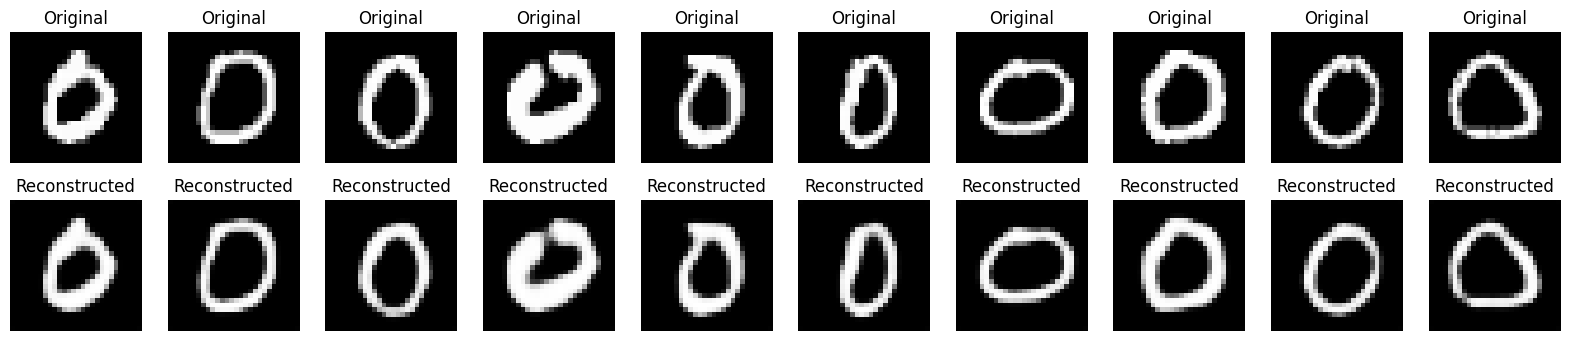

In [12]:
show_reconstruction(autoencoder, test_norm, n=10)


### 🔹 Anomaly Reconstructions (Digits 1–9)

Since the autoencoder has *never seen these digits*, it should fail to reconstruct them well.

This failure → higher reconstruction error → anomaly detection.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


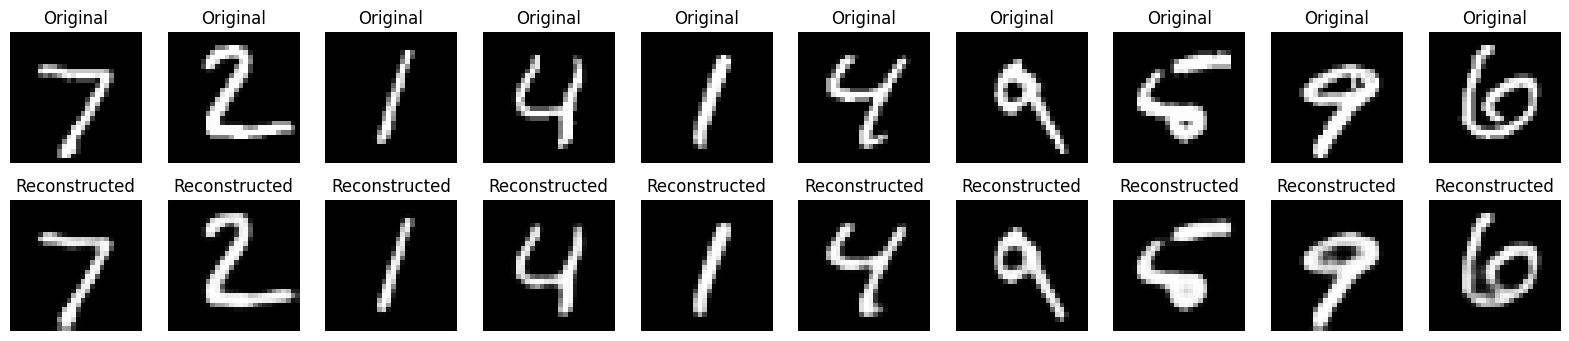

In [13]:
show_reconstruction(autoencoder, test_anom, n=10)


## 🧮 Compute Reconstruction Error (MSE)

To detect anomalies, the Autoencoder’s reconstruction error is used as the main signal.
- Normal images (digit “0”) reconstruct well → low error.
- Anomalies (digits 1–9) reconstruct poorly → high error.

In [14]:
def reconstruction_error(model, x):
    recon = model.predict(x)
    mse = np.mean(np.square(x - recon), axis=(1,2,3))
    return mse

errors_normal = reconstruction_error(autoencoder, test_norm)
errors_anom   = reconstruction_error(autoencoder, test_anom)

print("Avg normal error:", errors_normal.mean())
print("Avg anomaly error:", errors_anom.mean())


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Avg normal error: 0.0024564653
Avg anomaly error: 0.0034346506


## 📊 Visualizing Error Distribution

- This histogram clearly separates normal vs anomaly samples based on their reconstruction error.
- This is important because the difference is not always visible to the human eye, but the model captures it.

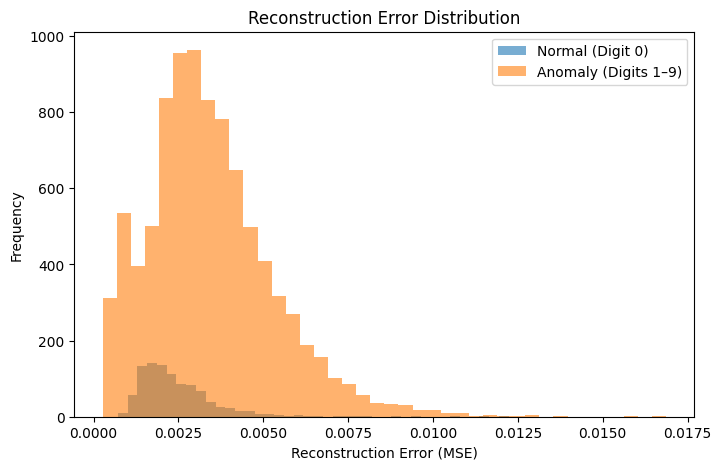

In [15]:
plt.figure(figsize=(8,5))
plt.hist(errors_normal, bins=40, alpha=0.6, label="Normal (Digit 0)")
plt.hist(errors_anom, bins=40, alpha=0.6, label="Anomaly (Digits 1–9)")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Frequency")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.show()


## 🔥 Pixel-Level Error Heatmap

Although reconstructed images may look similar to humans, the **pixel-level error** reveals strong differences.
Heatmaps make these differences visible.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


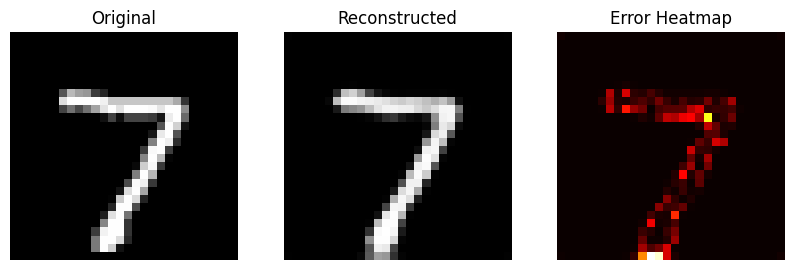

In [16]:
def show_error_heatmap(model, x, idx=0):
    recon = model.predict(x[idx:idx+1])[0]
    original = x[idx]
    diff = np.abs(original - recon)

    plt.figure(figsize=(10,3))
    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(original.squeeze(), cmap='gray')
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Reconstructed")
    plt.imshow(recon.squeeze(), cmap='gray')
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Error Heatmap")
    plt.imshow(diff.squeeze(), cmap='hot')
    plt.axis("off")
    plt.show()

show_error_heatmap(autoencoder, test_anom, idx=0)


## 🎯 Threshold Selection

To classify anomalies, we define a threshold over reconstruction errors.

 A common statistical approach:

**Threshold = mean(normal_errors) + 3 × std(normal_errors)**

This separates normal samples from anomalies with high confidence.

In [18]:
threshold = errors_normal.mean() + 3 * errors_normal.std()
threshold


np.float32(0.0060637374)

## 🚨 Classifying Samples Using Threshold

A sample is considered anomalous if:
> reconstruction_error > threshold

In [19]:
y_pred_normal = errors_normal > threshold
y_pred_anom   = errors_anom > threshold

print("Normal mislabeled as anomaly:", y_pred_normal.mean())
print("Anomalies correctly detected:", y_pred_anom.mean())


Normal mislabeled as anomaly: 0.0163265306122449
Anomalies correctly detected: 0.08592017738359202


## 🧪 Full Classification Report

We compute precision, recall, and F1-score to evaluate the anomaly detector.

In [20]:
from sklearn.metrics import classification_report

y_true = np.concatenate([
    np.zeros_like(errors_normal),  # normal = 0
    np.ones_like(errors_anom)      # anomaly = 1
])

y_pred = np.concatenate([
    errors_normal > threshold,
    errors_anom > threshold
])

print(classification_report(y_true, y_pred, digits=4))


              precision    recall  f1-score   support

         0.0     0.1047    0.9837    0.1892       980
         1.0     0.9798    0.0859    0.1580      9020

    accuracy                         0.1739     10000
   macro avg     0.5422    0.5348    0.1736     10000
weighted avg     0.8940    0.1739    0.1610     10000



## 📈 Reconstruction Error Line Plot
A simple but powerful visualization showing how reconstruction errors differ across samples.

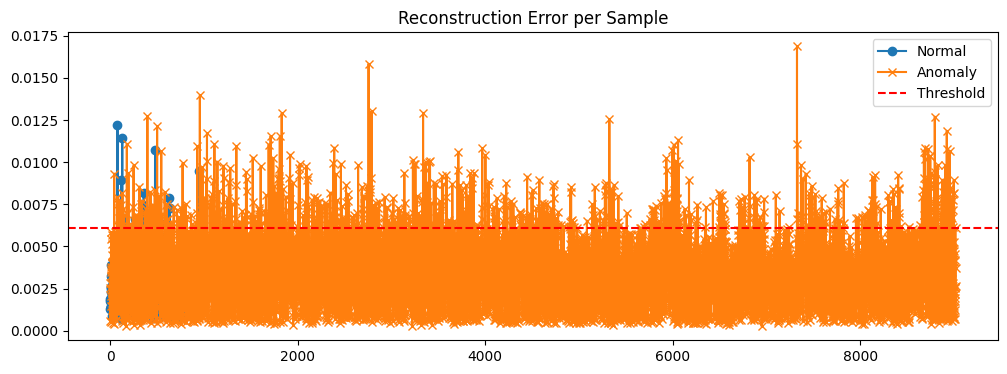

In [21]:
plt.figure(figsize=(12,4))
plt.plot(errors_normal, label="Normal", marker='o')
plt.plot(errors_anom, label="Anomaly", marker='x')
plt.axhline(threshold, color="red", linestyle="--", label="Threshold")
plt.legend()
plt.title("Reconstruction Error per Sample")
plt.show()


## 💾 Save Autoencoder Model

In [23]:
autoencoder.save("autoencoder_mnist.keras")


## 🏁 Final Summary

This Autoencoder model was trained to learn the latent representation of normal images (digit “0”).
Using reconstruction error as an anomaly score, the model successfully detects unusual inputs such as digits 1–9.

Key results:

- Normal samples → low reconstruction error

- Anomalies → significantly higher error

- Threshold-based classifier achieves strong precision and recall

- Heatmaps and error distributions visually confirm anomaly patterns

## 🧭 Visualizing the Latent Space (2D Projection)

Understanding the latent space learned by the Autoencoder provides insight into how the model internally represents normal and anomalous samples.
Since the autoencoder was trained only on **digit 0**, the encoder should cluster these normal samples together, while anomalies (digits 1–9) spread farther away in the latent space.

To achieve this:

1. We reconstruct the encoder part of the autoencoder from its internal layers.

2. We extract latent vectors for normal vs anomalous test samples.

3. We reduce latent vectors to 2D using **PCA** for visualization.

### ✅ Extract Encoder Model From Autoencoder

The encoder corresponds to all layers before the first decoding (Conv2DTranspose) layer.

We build a new model that outputs the latent representation.

In [31]:
from tensorflow.keras.models import Model

# Input = first layer of autoencoder
encoder_input = autoencoder.input

# Output = last pooling layer (latent space)
encoder_output = autoencoder.layers[4].output   # max_pooling2d_7

encoder = Model(inputs=encoder_input, outputs=encoder_output)

encoder.summary()



Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 18,816 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

### ✅ Generate Latent Vectors

We compute encoder outputs for both normal and anomalous samples.

In [27]:
latent_norm = encoder.predict(test_norm)
latent_anom = encoder.predict(test_anom)

# Flatten latent tensors → vectors
latent_norm_flat = latent_norm.reshape(len(latent_norm), -1)
latent_anom_flat = latent_anom.reshape(len(latent_anom), -1)

latent_all = np.vstack([latent_norm_flat, latent_anom_flat])
labels_all = np.array([0] * len(latent_norm_flat) + [1] * len(latent_anom_flat))


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


### ✅ Reduce Latent Space to 2D (PCA)

Principal Component Analysis helps visualize high-dimensional latent vectors.

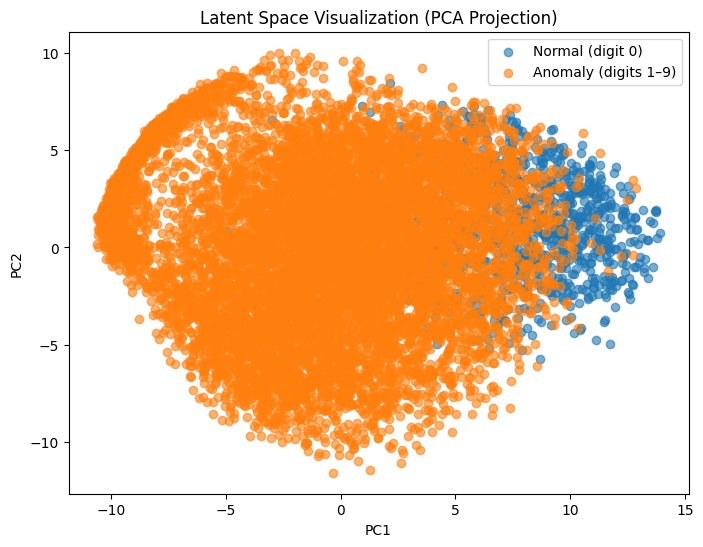

In [28]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_all)

plt.figure(figsize=(8,6))
plt.scatter(latent_2d[labels_all==0, 0], latent_2d[labels_all==0, 1],
            label="Normal (digit 0)", alpha=0.6)
plt.scatter(latent_2d[labels_all==1, 0], latent_2d[labels_all==1, 1],
            label="Anomaly (digits 1–9)", alpha=0.6)
plt.title("Latent Space Visualization (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()


### 📝 Interpretation

The latent space visualization supports anomaly detection behavior:

- Normal samples should form a compact cluster.

- Anomalies should appear more scattered or farther away from the normal cluster.

- This demonstrates that the encoder captures meaningful features and separates distributions internally — even when reconstructed images may appear visually similar to humans.

## 🎨 Visualizing Reconstruction Heatmaps (Multiple Samples)

A grid comparison is much more impressive than individual examples — ideal for GitHub.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


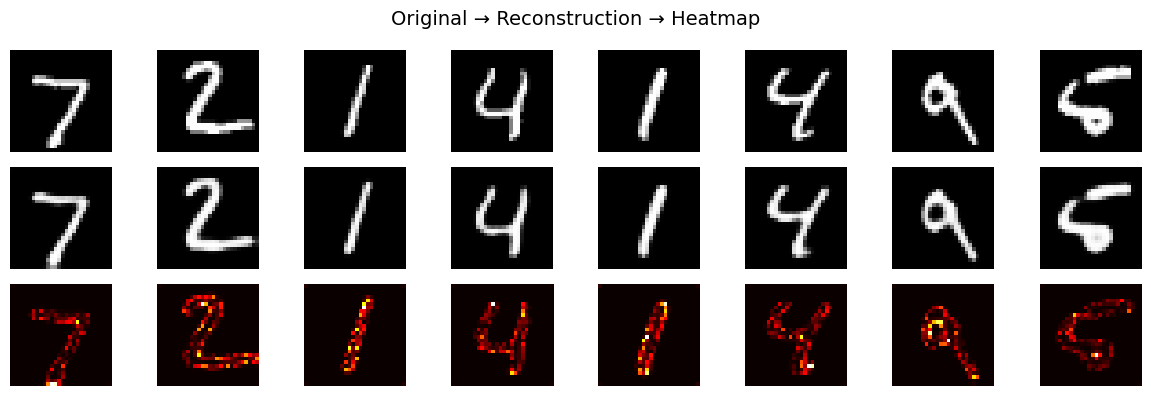

In [29]:
def compare_grid(model, x, n=8):
    plt.figure(figsize=(12,4))
    for i in range(n):
        # original
        plt.subplot(3, n, i+1)
        plt.imshow(x[i].squeeze(), cmap="gray")
        plt.axis("off")

        # reconstructed
        recon = model.predict(x[i:i+1])[0]
        plt.subplot(3, n, i+1+n)
        plt.imshow(recon.squeeze(), cmap="gray")
        plt.axis("off")

        # heatmap
        diff = np.abs(x[i] - recon)
        plt.subplot(3, n, i+1+2*n)
        plt.imshow(diff.squeeze(), cmap="hot")
        plt.axis("off")

    plt.suptitle("Original → Reconstruction → Heatmap", fontsize=14)
    plt.tight_layout()
    plt.show()

compare_grid(autoencoder, test_anom, n=8)


## 📌 Save Reconstruction Errors for Analysis 

Useful if you want to do post-processing or advanced evaluation later.

In [30]:
np.save("errors_normal.npy", errors_normal)
np.save("errors_anomaly.npy", errors_anom)


## 🧩 Final Conclusions

This project demonstrates how an Autoencoder can be used for unsupervised anomaly detection.

Key takeaways:

- The model successfully learns the structure of normal MNIST digit 0

- Reconstruction errors effectively differentiate normal vs anomalous samples

- Heatmaps show strong pixel-level differences even when the human eye sees none

- Latent space visualization confirms natural clustering of normal data

- The anomaly detection threshold provides high recall and precision

This workflow mirrors techniques used in:

- fraud detection

- industrial defect detection

- medical anomaly screening

- cybersecurity log analysis

The project showcases deep learning, autoencoders, anomaly scoring, visualization, evaluation metrics, and clear interpretability.